<a href="https://colab.research.google.com/github/cem8kaya/5g-ai-lab/blob/main/5G_AI_LAB_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 5G AI/ML Laboratory - Architecture Context Document

## 1. Overview
This environment is an end-to-end simulated 5G Network designed for generating telecommunications traffic data for Machine Learning and Data Science projects. It utilizes Open5GS for the Core Network and UERANSIM for the RAN/UE simulation.

## 2. Infrastructure Details
* **Platform:** Google Cloud Platform (GCP)
* **Project ID:** `g-ai-lab-491619`
* **Zone:** `europe-west4-a`
* **VM Name:** `open5gs-ai-lab`
* **OS:** Ubuntu 22.04 LTS (Kernel: 6.8.0-1048-gcp)
* **Execution Environment:** Google Colab (communicates with VM via `gcloud compute ssh` commands).

## 3. 5G Core Network (Open5GS)
* **Services:** AMF, UPF, SMF, UDM, AUSF, etc. (Running as `systemd` services, e.g., `open5gs-amfd`).
* **Kernel Module:** `gtp5g` is compiled and loaded successfully for UPF packet routing.
* **WebUI:** Accessible externally via port `9999` (e.g., `http://<EXTERNAL_IP>:9999`).
* **Default Network Configuration:** * PLMN: `999-70` (MCC: 999, MNC: 70)

## 4. RAN & UE Simulation (UERANSIM)
* **Installation Path:** Compiled from source, binaries located at `/opt/UERANSIM/build/`.
* **Configuration Files:** * gNodeB: `/opt/UERANSIM/config/open5gs-gnb.yaml` (Configured for PLMN 999-70)
    * UE: `/opt/UERANSIM/config/open5gs-ue.yaml` (Configured for PLMN 999-70)
* **Subscriber Details (Registered in Open5GS WebUI):**
    * **IMSI:** `999700000000001`
    * **Subscriber Key (K):** `465B5CE8 B199B49F AA5F0A2E E238A6BC`
    * **OPc:** `E8ED289D EBA952E4 283B54E8 8E6183CA`
* **Tunnel Interface:** When the UE establishes a PDU session, it creates a virtual network interface named `uesimtun0` (Assigned IP usually `10.45.0.2`).

## 5. Data Science Pipeline (ETL)
* **Traffic Generation:** Synthetic traffic (ICMP, TCP, HTTP) is generated on the GCP VM using `ping` and `curl` bound to the `uesimtun0` interface.
* **Data Capture:** `tcpdump` captures the raw packets into a `.pcap` file (`/tmp/5g_traffic.pcap`).
* **Data Processing:** The `.pcap` file is transferred to Google Colab, where the Python `scapy` library parses it.
* **Current State:** A Pandas DataFrame is active with features including `Zaman` (Timestamp), `Kaynak_IP`, `Hedef_IP`, `Protokol`, `Boyut_Byte`, `Zaman_Farki_sn` (Inter-arrival time), and `Yon` (Uplink/Downlink).

# Hücre 0: Bağımlılıklar

In [ ]:
# 1. GCP'ye Kimlik Doğrulaması
from google.colab import auth
auth.authenticate_user()
print("Kimlik doğrulaması başarılı!")

Kimlik doğrulaması başarılı!


In [ ]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
    'pandas', 'scapy', 'matplotlib', 'seaborn', 'numpy'])
print("✅ Tüm bağımlılıklar hazır.")

✅ Tüm bağımlılıklar hazır.


# Hücre 1: Konfigürasyon

In [ ]:
PROJECT_ID = "g-ai-lab-491619"
ZONE       = "europe-west4-a"
VM_NAME    = "open5gs-ai-lab"
UE_IP      = "10.45.0.3"
UE_IFACE   = "uesimtun0"
NR_BINDER  = "/opt/UERANSIM/build/nr-binder"

print(f"✅ Konfigürasyon yüklendi — VM: {VM_NAME} | UE: {UE_IP}")

✅ Konfigürasyon yüklendi — VM: open5gs-ai-lab | UE: 10.45.0.3


# Hücre 2: Sağlık Kontrolü

In [ ]:
%%bash
PROJECT_ID="g-ai-lab-491619"; ZONE="europe-west4-a"; VM_NAME="open5gs-ai-lab"

gcloud compute ssh $VM_NAME --project=$PROJECT_ID --zone=$ZONE --command="
    echo '=== 5G Core Servisleri ==='
    for svc in amfd smfd upfd ausfd udmd pcfd nrfd; do
        STATUS=\$(systemctl is-active open5gs-\$svc 2>/dev/null)
        printf '  %-12s: %s\n' \$svc \$STATUS
    done

    echo ''
    echo '=== UERANSIM ==='
    pgrep -a nr-gnb && echo 'gNB: calisiyor' || echo 'gNB: DURDU'
    pgrep -a nr-ue  && echo 'UE : calisiyor' || echo 'UE : DURDU'

    echo ''
    echo '=== PDU Session ==='
    ip a show uesimtun0 | grep inet | awk '{print \$2}'

    echo ''
    echo '=== UPF Session Sayisi ==='
    curl -s http://127.0.0.7:9090/metrics 2>/dev/null | \
        grep 'upf_sessionnbr' | grep -v '#'
"

=== 5G Core Servisleri ===
  amfd        : active
  smfd        : active
  upfd        : active
  ausfd       : active
  udmd        : active
  pcfd        : active
  nrfd        : active

=== UERANSIM ===
42148 /opt/UERANSIM/build/nr-gnb -c /opt/UERANSIM/config/open5gs-gnb.yaml
gNB: calisiyor
69053 /opt/UERANSIM/build/nr-ue -c /opt/UERANSIM/config/open5gs-ue.yaml
UE : calisiyor

=== PDU Session ===
10.45.0.5/24
fe80::77b8:d43e:d3ea:4e38/64

=== UPF Session Sayisi ===
fivegs_upffunction_upf_sessionnbr 1


# Hücre 3: Senaryo A — Genel Trafik Profili

In [ ]:
%%bash
PROJECT_ID="g-ai-lab-491619"; ZONE="europe-west4-a"; VM_NAME="open5gs-ai-lab"

cat > /tmp/scenario_a.sh << 'SCRIPT'
#!/bin/bash
LOG="/tmp/scenario_a.csv"
NR="/opt/UERANSIM/build"
UE="uesimtun0"
echo "timestamp_ms,scenario,ue_ip,target,protocol,bytes,rtt_ms,status" > $LOG

log() { echo "$(date +%s%3N),$1,10.45.0.3,$2,$3,$4,$5,$6" >> $LOG; }

echo "[A] ICMP — 20 ping"
for i in $(seq 1 20); do
    cd $NR
    RESULT=$(./nr-binder $UE ping -c 1 -q 8.8.8.8 2>&1)
    RTT=$(echo "$RESULT" | grep rtt | awk -F'/' '{print $5}')
    LOSS=$(echo "$RESULT" | grep transmitted | awk '{print $6}' | tr -d '%')
    STATUS=$([ "${LOSS:-100}" -eq 0 ] && echo "OK" || echo "LOSS")
    log "A_ICMP" "8.8.8.8" "ICMP" "84" "${RTT:-0}" "$STATUS"
    sleep 0.5
done

echo "[A] HTTP — web browse pattern"
for URL in \
    "http://neverssl.com" \
    "https://www.google.com" \
    "https://www.cloudflare.com" \
    "http://neverssl.com" \
    "https://www.google.com"; do
    cd $NR
    RESULT=$(./nr-binder $UE curl -s -o /dev/null \
        -w "%{size_download}|%{time_total}" \
        --max-time 15 "$URL" 2>/dev/null || echo "0|0")
    SIZE=$(echo $RESULT | cut -d'|' -f1)
    TIME=$(echo $RESULT | cut -d'|' -f2 | awk '{printf "%.0f", $1*1000}')
    STATUS=$([ "${SIZE:-0}" -gt 0 ] && echo "OK" || echo "FAIL")
    HOST=$(echo $URL | awk -F'/' '{print $3}')
    log "A_HTTP" "$HOST" "HTTP" "${SIZE:-0}" "${TIME:-0}" "$STATUS"
    sleep $(awk 'BEGIN{srand(); printf "%d", 1+rand()*3}')
done

echo "[A] DNS — latency olcumu"
for DOMAIN in google.com cloudflare.com github.com amazon.com; do
    cd $NR
    DNS_TIME=$(./nr-binder $UE curl -s -o /dev/null \
        -w "%{time_namelookup}" \
        --max-time 5 "https://$DOMAIN" 2>/dev/null || echo "0")
    DNS_MS=$(echo $DNS_TIME | awk '{printf "%.0f", $1*1000}')
    log "A_DNS" "$DOMAIN" "DNS" "0" "${DNS_MS:-0}" "OK"
done

# BURST: google.com hedefi, sleep 1.0, max-time 10
echo "[A] Burst — 10 hizli istek (google.com)"
for i in $(seq 1 10); do
    cd $NR
    RESULT=$(./nr-binder $UE curl -s -o /dev/null \
        -w "%{size_download}|%{time_total}" \
        --max-time 10 "https://www.google.com" 2>/dev/null || echo "0|0")
    SIZE=$(echo $RESULT | cut -d'|' -f1)
    TIME=$(echo $RESULT | cut -d'|' -f2 | awk '{printf "%.0f", $1*1000}')
    STATUS=$([ "${SIZE:-0}" -gt 0 ] && echo "OK" || echo "FAIL")
    log "A_BURST" "www.google.com" "HTTP" "${SIZE:-0}" "${TIME:-0}" "$STATUS"
    sleep 1
done

echo "=== TAMAMLANDI: $(( $(wc -l < $LOG) - 1 )) kayit ==="
cat $LOG
SCRIPT

gcloud compute scp /tmp/scenario_a.sh $VM_NAME:/tmp/scenario_a.sh \
    --project=$PROJECT_ID --zone=$ZONE

gcloud compute ssh $VM_NAME --project=$PROJECT_ID --zone=$ZONE \
    --command="sudo bash /tmp/scenario_a.sh"

[A] ICMP — 20 ping
[A] HTTP — web browse pattern
[A] DNS — latency olcumu
[A] Burst — 10 hizli istek (google.com)
=== TAMAMLANDI: 39 kayit ===
timestamp_ms,scenario,ue_ip,target,protocol,bytes,rtt_ms,status
1774813798578,A_ICMP,10.45.0.3,8.8.8.8,ICMP,84,0.552,OK
1774813799117,A_ICMP,10.45.0.3,8.8.8.8,ICMP,84,0.261,OK
1774813799632,A_ICMP,10.45.0.3,8.8.8.8,ICMP,84,0.298,OK
1774813800147,A_ICMP,10.45.0.3,8.8.8.8,ICMP,84,0.272,OK
1774813800664,A_ICMP,10.45.0.3,8.8.8.8,ICMP,84,0.331,OK
1774813801180,A_ICMP,10.45.0.3,8.8.8.8,ICMP,84,0.320,OK
1774813801696,A_ICMP,10.45.0.3,8.8.8.8,ICMP,84,0.338,OK
1774813802211,A_ICMP,10.45.0.3,8.8.8.8,ICMP,84,0.376,OK
1774813802727,A_ICMP,10.45.0.3,8.8.8.8,ICMP,84,0.303,OK
1774813803244,A_ICMP,10.45.0.3,8.8.8.8,ICMP,84,0.418,OK
1774813803759,A_ICMP,10.45.0.3,8.8.8.8,ICMP,84,0.278,OK
1774813804275,A_ICMP,10.45.0.3,8.8.8.8,ICMP,84,0.353,OK
1774813804791,A_ICMP,10.45.0.3,8.8.8.8,ICMP,84,0.313,OK
1774813805305,A_ICMP,10.45.0.3,8.8.8.8,ICMP,84,0.287,OK
177481380

# Hücre 4: Senaryo B — Etiketli Anomali Dataset

In [ ]:
%%bash
PROJECT_ID="g-ai-lab-491619"; ZONE="europe-west4-a"; VM_NAME="open5gs-ai-lab"

cat > /tmp/scenario_b.sh << 'SCRIPT'
#!/bin/bash
LOG="/tmp/scenario_b.csv"
NR="/opt/UERANSIM/build"
UE="uesimtun0"
echo "timestamp_ms,label,ue_ip,target,protocol,bytes,rtt_ms,pkt_rate" > $LOG

log() { echo "$(date +%s%3N),$1,10.45.0.3,$2,$3,$4,$5,$6" >> $LOG; }

# ── NORMAL: yavaş ritmik web browsing ────────────────────────────────────────
echo "[B] NORMAL — web browsing (15 istek, rasgele araliklar)"
for i in $(seq 1 15); do
    cd $NR
    RESULT=$(./nr-binder $UE curl -s -o /dev/null \
        -w "%{size_download}|%{time_total}" \
        --max-time 10 "https://www.google.com" 2>/dev/null || echo "0|0")
    SIZE=$(echo $RESULT | cut -d'|' -f1)
    TIME=$(echo $RESULT | cut -d'|' -f2 | awk '{printf "%.0f", $1*1000}')
    log "NORMAL" "www.google.com" "HTTP" "${SIZE:-0}" "${TIME:-0}" "1"
    sleep $(awk 'BEGIN{srand('$i'); printf "%.1f", 2+rand()*4}')
done

# ── NORMAL: periyodik IoT heartbeat ──────────────────────────────────────────
echo "[B] NORMAL — IoT heartbeat (20 ping, 2s aralik)"
for i in $(seq 1 20); do
    cd $NR
    RTT=$(./nr-binder $UE ping -c 1 -q 8.8.8.8 2>&1 | \
        grep rtt | awk -F'/' '{print $5}')
    log "NORMAL" "8.8.8.8" "ICMP" "84" "${RTT:-0}" "0.5"
    sleep 2
done

# ── ANOMALY_SCAN: cok hizli ardisik HTTP istekleri ───────────────────────────
echo "[B] ANOMALY_SCAN — 30 paralel hizli istek"
SCAN_START=$(date +%s%3N)
for i in $(seq 1 30); do
    cd $NR
    (./nr-binder $UE curl -s -o /dev/null \
        --connect-timeout 1 --max-time 2 \
        "https://www.google.com" 2>/dev/null) &
    log "ANOMALY_SCAN" "www.google.com" "HTTP" "0" "0" "30"
done
wait
SCAN_END=$(date +%s%3N)
echo "  Scan suresi: $(( SCAN_END - SCAN_START ))ms"

# ── ANOMALY_FLOOD: ICMP flood ─────────────────────────────────────────────────
echo "[B] ANOMALY_FLOOD — 50 paralel ICMP"
for i in $(seq 1 50); do
    cd $NR
    (./nr-binder $UE ping -c 1 -q 8.8.8.8 > /dev/null 2>&1) &
    log "ANOMALY_FLOOD" "8.8.8.8" "ICMP" "84" "0" "50"
done
wait

# ── ANOMALY_SLOWLORIS: yavash buyuk HTTP istegi ───────────────────────────────
echo "[B] ANOMALY_SLOWLORIS — 5x buyuk/yavas indirme"
for i in $(seq 1 5); do
    cd $NR
    RESULT=$(./nr-binder $UE curl -s -o /dev/null \
        -w "%{size_download}|%{time_total}" \
        --max-time 20 "https://www.cloudflare.com" 2>/dev/null || echo "0|0")
    SIZE=$(echo $RESULT | cut -d'|' -f1)
    TIME=$(echo $RESULT | cut -d'|' -f2 | awk '{printf "%.0f", $1*1000}')
    log "ANOMALY_SLOWLORIS" "www.cloudflare.com" "HTTP" "${SIZE:-0}" "${TIME:-0}" "0.1"
    sleep 0.5
done

# ── ANOMALY_EXFIL: buyuk dosya indirme ────────────────────────────────────────
echo "[B] ANOMALY_EXFIL — buyuk dosya transferi"
cd $NR
RESULT=$(./nr-binder $UE curl -s -o /dev/null \
    -w "%{size_download}|%{time_total}" \
    --max-time 30 "http://speedtest.tele2.net/1MB.zip" 2>/dev/null || echo "0|0")
SIZE=$(echo $RESULT | cut -d'|' -f1)
TIME=$(echo $RESULT | cut -d'|' -f2 | awk '{printf "%.0f", $1*1000}')
log "ANOMALY_EXFIL" "speedtest.tele2.net" "HTTP" "${SIZE:-0}" "${TIME:-0}" "0.03"

echo ""
echo "=== TAMAMLANDI ==="
echo "Label dagilimi:"
tail -n +2 $LOG | cut -d',' -f2 | sort | uniq -c | sort -rn

echo ""
echo "Toplam kayit: $(( $(wc -l < $LOG) - 1 ))"
SCRIPT

gcloud compute scp /tmp/scenario_b.sh $VM_NAME:/tmp/scenario_b.sh \
    --project=$PROJECT_ID --zone=$ZONE

gcloud compute ssh $VM_NAME --project=$PROJECT_ID --zone=$ZONE \
    --command="sudo bash /tmp/scenario_b.sh"

[B] NORMAL — web browsing (15 istek, rasgele araliklar)
[B] NORMAL — IoT heartbeat (20 ping, 2s aralik)
[B] ANOMALY_SCAN — 30 paralel hizli istek
  Scan suresi: 1287ms
[B] ANOMALY_FLOOD — 50 paralel ICMP
[B] ANOMALY_SLOWLORIS — 5x buyuk/yavas indirme
[B] ANOMALY_EXFIL — buyuk dosya transferi

=== TAMAMLANDI ===
Label dagilimi:
     50 ANOMALY_FLOOD
     35 NORMAL
     30 ANOMALY_SCAN
      5 ANOMALY_SLOWLORIS
      1 ANOMALY_EXFIL

Toplam kayit: 121


# Hücre 5: Senaryo C — Zaman Serisi Metrikler (UPF + Interface)

In [ ]:
%%bash
PROJECT_ID="g-ai-lab-491619"; ZONE="europe-west4-a"; VM_NAME="open5gs-ai-lab"

gcloud compute ssh $VM_NAME --project=$PROJECT_ID --zone=$ZONE --command="
    echo '=== Aktif UE tunnel ==='
    ip a | grep -A2 'uesimtun'

    echo ''
    echo '=== /proc/net/dev uesimtun0 ==='
    grep 'uesimtun0' /proc/net/dev || echo 'BULUNAMADI'

    echo ''
    echo '=== UE process ==='
    pgrep -a nr-ue || echo 'UE calismıyor'

    echo ''
    echo '=== UPF Session ==='
    curl -s http://127.0.0.7:9090/metrics 2>/dev/null | \
        grep 'upf_sessionnbr' | grep -v '#'
"

=== Aktif UE tunnel ===
32: uesimtun0: <POINTOPOINT,PROMISC,NOTRAILERS,UP,LOWER_UP> mtu 1400 qdisc fq_codel state UNKNOWN group default qlen 500
    link/none 
    inet 10.45.0.5/24 scope global uesimtun0
       valid_lft forever preferred_lft forever
    inet6 fe80::e1f0:6ca6:15aa:ad95/64 scope link stable-privacy 

=== /proc/net/dev uesimtun0 ===
uesimtun0:       0       0    0    0    0     0          0         0      688      12    0    0    0     0       0          0

=== UE process ===
74325 /opt/UERANSIM/build/nr-ue -c /opt/UERANSIM/config/open5gs-ue.yaml

=== UPF Session ===
fivegs_upffunction_upf_sessionnbr 1


In [ ]:
%%bash
PROJECT_ID="g-ai-lab-491619"; ZONE="europe-west4-a"; VM_NAME="open5gs-ai-lab"

cat > /tmp/scenario_c.sh << 'SCRIPT'
#!/bin/bash
LOG="/tmp/scenario_c.csv"
NR="/opt/UERANSIM/build"
DURATION=90
INTERVAL=3

echo "timestamp_ms,phase,ue_tx_kbps,ue_rx_kbps,ogstun_tx_kbps,ogstun_rx_kbps,ens4_tx_kbps,ens4_rx_kbps,upf_sessions" > $LOG

# ── Aktif interface'i bul ─────────────────────────────────────────────────────
get_ue_iface() {
    for iface in uesimtun0 uesimtun1 uesimtun2 uesimtun3; do
        IP=$(ip a show $iface 2>/dev/null | grep 'inet ' | \
            awk '{print $2}' | cut -d'/' -f1)
        [ -n "$IP" ] && echo "$iface" && return
    done
    echo ""
}

# ── Trafik yoksa UE'yi yeniden başlat ────────────────────────────────────────
echo "=== UE durumu kontrol ==="
UE_IFACE=$(get_ue_iface)
if [ -z "$UE_IFACE" ]; then
    echo "  UE tunnel yok, yeniden baslatiliyor..."
    sudo pkill -f nr-ue || true
    sleep 2
    sudo nohup $NR/nr-ue \
        -c /opt/UERANSIM/config/open5gs-ue.yaml > /root/ue.log 2>&1 &
    for i in $(seq 1 40); do
        sleep 0.5
        UE_IFACE=$(get_ue_iface)
        [ -n "$UE_IFACE" ] && break
    done
fi

if [ -z "$UE_IFACE" ]; then
    echo "HATA: UE tunnel olusturulamadi"; exit 1
fi

UE_IP=$(ip a show $UE_IFACE | grep 'inet ' | awk '{print $2}' | cut -d'/' -f1)
echo "  Aktif: $UE_IFACE ($UE_IP)"

# ── /proc/net/dev okuma ───────────────────────────────────────────────────────
read_bytes() {
    # $1=interface adı, rx=col2, tx=col10
    grep "${1}:" /proc/net/dev 2>/dev/null | \
        awk '{gsub(/:/," "); print $2, $10}'
}

# ── KB/s hesabı (python3, ms cinsinden dt) ────────────────────────────────────
calc_kbps() {
    python3 -c "
b1,b2,dt_ms = $1,$2,$3
diff = max(0, b2 - b1)
kbps = round(diff / (dt_ms/1000) / 1024, 2) if dt_ms > 0 else 0
print(kbps)
" 2>/dev/null || echo "0"
}

# ── Warm-up trafiği: counter'ları sıfırdan kaldır ─────────────────────────────
echo "=== Warm-up (10sn trafik) ==="
cd $NR
./nr-binder $UE_IFACE ping -c 5 8.8.8.8 > /dev/null 2>&1
./nr-binder $UE_IFACE curl -s -o /dev/null --max-time 8 \
    "https://www.google.com" > /dev/null 2>&1
sleep 2

# Warm-up sonrası ilk okuma
read UE_RX1 UE_TX1 <<< $(read_bytes $UE_IFACE)
read OG_RX1 OG_TX1 <<< $(read_bytes ogstun)
read E4_RX1 E4_TX1 <<< $(read_bytes ens4)
T_PREV_MS=$(date +%s%3N)
echo "  Baslangic sayac: UE_TX=$UE_TX1 UE_RX=$UE_RX1"

# ── Arka plan trafik fazları ──────────────────────────────────────────────────
(
  echo "[Trafik] normal faz basliyor..."
  for i in $(seq 1 4); do
    cd $NR
    ./nr-binder $UE_IFACE ping -c 5 8.8.8.8 > /dev/null 2>&1
    ./nr-binder $UE_IFACE curl -s -o /dev/null --max-time 10 \
        "https://www.google.com" > /dev/null 2>&1
    sleep 3
  done

  echo "[Trafik] burst faz basliyor..."
  for i in $(seq 1 8); do
    cd $NR
    ./nr-binder $UE_IFACE curl -s -o /dev/null --max-time 8 \
        "https://www.cloudflare.com" > /dev/null 2>&1 &
  done
  wait; sleep 2

  echo "[Trafik] idle faz..."
  sleep 15

  echo "[Trafik] burst2 faz basliyor..."
  for i in $(seq 1 5); do
    cd $NR
    ./nr-binder $UE_IFACE curl -s -o /dev/null --max-time 10 \
        "https://www.google.com" > /dev/null 2>&1
    ./nr-binder $UE_IFACE ping -c 3 8.8.8.8 > /dev/null 2>&1
    sleep 2
  done
  echo "[Trafik] tamamlandi."
) &
TRAFFIC_PID=$!

sleep $INTERVAL

# ── Ana ölçüm döngüsü ─────────────────────────────────────────────────────────
T_START=$(date +%s)
END=$(( T_START + DURATION ))

echo ""
echo "=== Olcum basladi ==="

while [ $(date +%s) -lt $END ]; do
    TS=$(date +%s%3N)
    ELAPSED=$(( $(date +%s) - T_START ))

    if   [ $ELAPSED -lt 30 ]; then PHASE="normal"
    elif [ $ELAPSED -lt 45 ]; then PHASE="burst"
    elif [ $ELAPSED -lt 60 ]; then PHASE="idle"
    else                            PHASE="burst2"
    fi

    # Yeni sayac değerleri
    read UE_RX2 UE_TX2 <<< $(read_bytes $UE_IFACE)
    read OG_RX2 OG_TX2 <<< $(read_bytes ogstun)
    read E4_RX2 E4_TX2 <<< $(read_bytes ens4)
    DT_MS=$(( TS - T_PREV_MS ))

    # Sayaçlar geçerli mi kontrol et
    if [ -z "$UE_TX2" ] || [ -z "$UE_RX2" ]; then
        # Interface kaybolmuş — yeniden bul
        UE_IFACE=$(get_ue_iface)
        [ -z "$UE_IFACE" ] && echo "  UYARI: UE tunnel kayboldu!" && sleep $INTERVAL && continue
        read UE_RX2 UE_TX2 <<< $(read_bytes $UE_IFACE)
    fi

    UE_TX_K=$(calc_kbps ${UE_TX1:-0} ${UE_TX2:-0} $DT_MS)
    UE_RX_K=$(calc_kbps ${UE_RX1:-0} ${UE_RX2:-0} $DT_MS)
    OG_TX_K=$(calc_kbps ${OG_TX1:-0} ${OG_TX2:-0} $DT_MS)
    OG_RX_K=$(calc_kbps ${OG_RX1:-0} ${OG_RX2:-0} $DT_MS)
    E4_TX_K=$(calc_kbps ${E4_TX1:-0} ${E4_TX2:-0} $DT_MS)
    E4_RX_K=$(calc_kbps ${E4_RX1:-0} ${E4_RX2:-0} $DT_MS)

    SESS=$(curl -s http://127.0.0.7:9090/metrics 2>/dev/null | \
        grep 'upf_sessionnbr' | grep -v '#' | awk '{print $2}' || echo 0)

    echo "${TS},${PHASE},${UE_TX_K},${UE_RX_K},${OG_TX_K},${OG_RX_K},${E4_TX_K},${E4_RX_K},${SESS:-0}" >> $LOG

    printf "  [%2ds|%-7s] UE_TX=%-10s UE_RX=%-10s KB/s  (delta_ms=%s)\n" \
        "$ELAPSED" "$PHASE" "$UE_TX_K" "$UE_RX_K" "$DT_MS"

    # Öncekine ata
    UE_RX1=$UE_RX2; UE_TX1=$UE_TX2
    OG_RX1=$OG_RX2; OG_TX1=$OG_TX2
    E4_RX1=$E4_RX2; E4_TX1=$E4_TX2
    T_PREV_MS=$TS

    sleep $INTERVAL
done

wait $TRAFFIC_PID 2>/dev/null

echo ""
echo "=== TAMAMLANDI: $(( $(wc -l < $LOG) - 1 )) adim ==="
echo "Max UE_TX KB/s:"
tail -n +2 $LOG | awk -F',' '{if($3+0>max) max=$3+0} END{printf "  %.2f\n",max}'
echo "Max UE_RX KB/s:"
tail -n +2 $LOG | awk -F',' '{if($4+0>max) max=$4+0} END{printf "  %.2f\n",max}'
echo "Sifir olmayan adim sayisi:"
tail -n +2 $LOG | awk -F',' '{if($3+0>0 || $4+0>0) n++} END{print "  "n+0}'
SCRIPT

gcloud compute scp /tmp/scenario_c.sh $VM_NAME:/tmp/scenario_c.sh \
    --project=$PROJECT_ID --zone=$ZONE

gcloud compute ssh $VM_NAME --project=$PROJECT_ID --zone=$ZONE \
    --command="sudo bash /tmp/scenario_c.sh"

gcloud compute scp $VM_NAME:/tmp/scenario_c.csv ./scenario_c.csv \
    --project=$PROJECT_ID --zone=$ZONE
echo "✅ scenario_c.csv: $(( $(wc -l < ./scenario_c.csv) - 1 )) adim"

=== UE durumu kontrol ===
  Aktif: uesimtun0 (10.45.0.5)
=== Warm-up (10sn trafik) ===
  Baslangic sayac: UE_TX=688 UE_RX=0
[Trafik] normal faz basliyor...

=== Olcum basladi ===
  [ 0s|normal ] UE_TX=0.0        UE_RX=0.0        KB/s  (delta_ms=3006)
  [ 4s|normal ] UE_TX=0.0        UE_RX=0.0        KB/s  (delta_ms=3129)
  [ 7s|normal ] UE_TX=0.0        UE_RX=0.0        KB/s  (delta_ms=3133)
  [10s|normal ] UE_TX=0.0        UE_RX=0.0        KB/s  (delta_ms=3133)
  [13s|normal ] UE_TX=0.0        UE_RX=0.0        KB/s  (delta_ms=3126)
  [16s|normal ] UE_TX=0.0        UE_RX=0.0        KB/s  (delta_ms=3126)
  [19s|normal ] UE_TX=0.0        UE_RX=0.0        KB/s  (delta_ms=3124)
  [22s|normal ] UE_TX=0.0        UE_RX=0.0        KB/s  (delta_ms=3124)
  [25s|normal ] UE_TX=0.0        UE_RX=0.0        KB/s  (delta_ms=3124)
[Trafik] burst faz basliyor...
  [29s|normal ] UE_TX=0.0        UE_RX=0.0        KB/s  (delta_ms=3130)
[Trafik] idle faz...
  [32s|burst  ] UE_TX=0.0        UE_RX=0.0       

# Hücre 6: Tüm Veriyi İndir

In [ ]:
%%bash
PROJECT_ID="g-ai-lab-491619"; ZONE="europe-west4-a"; VM_NAME="open5gs-ai-lab"

for FILE in scenario_a.csv scenario_b.csv scenario_c.csv; do
    gcloud compute scp $VM_NAME:/tmp/$FILE ./$FILE \
        --project=$PROJECT_ID --zone=$ZONE 2>/dev/null \
        && echo "✅ $FILE — $(( $(wc -l < ./$FILE) - 1 )) kayit" \
        || echo "❌ $FILE indirilemedi"
done

✅ scenario_a.csv — 39 kayit
✅ scenario_b.csv — 121 kayit
✅ scenario_c.csv — 29 kayit


# Hücre 7: ETL — DataFrame'lere Yükle

In [ ]:
import pandas as pd
import numpy as np
import os

dfs = {}

if os.path.exists('scenario_a.csv'):
    df_a = pd.read_csv('scenario_a.csv')
    df_a['timestamp'] = pd.to_datetime(df_a['timestamp_ms'], unit='ms')
    df_a['rtt_ms']    = pd.to_numeric(df_a['rtt_ms'], errors='coerce').fillna(0)
    df_a['bytes']     = pd.to_numeric(df_a['bytes'],  errors='coerce').fillna(0)
    dfs['A'] = df_a
    print(f"✅ Senaryo A: {len(df_a)} kayit")
    print(df_a['scenario'].value_counts().to_string(), "\n")

if os.path.exists('scenario_b.csv'):
    df_b = pd.read_csv('scenario_b.csv')
    df_b['timestamp']  = pd.to_datetime(df_b['timestamp_ms'], unit='ms')
    df_b['rtt_ms']     = pd.to_numeric(df_b['rtt_ms'], errors='coerce').fillna(0)
    df_b['bytes']      = pd.to_numeric(df_b['bytes'],  errors='coerce').fillna(0)
    df_b['is_anomaly'] = df_b['label'].str.startswith('ANOMALY').astype(int)
    dfs['B'] = df_b
    print(f"✅ Senaryo B: {len(df_b)} kayit")
    print(df_b['label'].value_counts().to_string(), "\n")

if os.path.exists('scenario_c.csv'):
    df_c = pd.read_csv('scenario_c.csv')
    df_c['timestamp'] = pd.to_datetime(df_c['timestamp_ms'], unit='ms')
    for col in ['ogstun_rx_kbps','ogstun_tx_kbps','ue_rx_kbps','ue_tx_kbps','ens4_rx_kbps','ens4_tx_kbps']:
        df_c[col] = pd.to_numeric(df_c[col], errors='coerce').fillna(0)
        df_c[f'{col}_diff'] = df_c[col].diff().fillna(0).clip(lower=0)
    dfs['C'] = df_c
    print(f"✅ Senaryo C: {len(df_c)} zaman adimi\n")

print("✅ Tum datasetler yuklu.")

✅ Senaryo A: 39 kayit
scenario
A_ICMP     20
A_BURST    10
A_HTTP      5
A_DNS       4 

✅ Senaryo B: 121 kayit
label
ANOMALY_FLOOD        50
NORMAL               35
ANOMALY_SCAN         30
ANOMALY_SLOWLORIS     5
ANOMALY_EXFIL         1 

✅ Senaryo C: 29 zaman adimi

✅ Tum datasetler yuklu.


# Hücre 8: Feature Engineering

In [ ]:
for df, name in [(dfs.get('A'), 'A'), (dfs.get('B'), 'B')]:
    if df is None: continue
    df['inter_arrival_ms'] = df['timestamp'].diff().dt.total_seconds().mul(1000).fillna(0)
    df['bytes_per_ms']     = np.where(df['rtt_ms'] > 0, df['bytes'] / df['rtt_ms'], 0)
    df['is_dns']           = (df['protocol'] == 'DNS').astype(int)
    df['is_icmp']          = (df['protocol'] == 'ICMP').astype(int)
    df['is_http']          = (df['protocol'] == 'HTTP').astype(int)
    df['rtt_zscore']       = (df['rtt_ms'] - df['rtt_ms'].mean()) / (df['rtt_ms'].std() + 1e-9)
    print(f"✅ Senaryo {name} feature engineering tamamlandi")
    print(df[['rtt_ms','bytes','inter_arrival_ms','bytes_per_ms','rtt_zscore']].describe().round(2))
    print()

✅ Senaryo A feature engineering tamamlandi
        rtt_ms      bytes  inter_arrival_ms  bytes_per_ms  rtt_zscore
count    39.00      39.00             39.00         39.00       39.00
mean    238.96   49678.41           1039.72        522.34        0.00
std    1228.57  157504.07           1584.96        581.28        1.00
min       0.26       0.00              0.00          0.00       -0.19
25%       0.32      84.00            515.00        240.72       -0.19
50%       0.55      84.00            516.00        281.88       -0.19
75%      78.50   79151.50           1099.50        977.04       -0.13
max    7701.00  981677.00           9725.00       3197.64        6.07

✅ Senaryo B feature engineering tamamlandi
       rtt_ms       bytes  inter_arrival_ms  bytes_per_ms  rtt_zscore
count  121.00      121.00            121.00        121.00      121.00
mean    23.50    59097.99            888.66        350.94       -0.00
std     64.01   215822.18           1475.95        852.67        1.00
min

# Hücre 9: Görselleştirme

/tmp/ipykernel_15988/2305778100.py:82: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


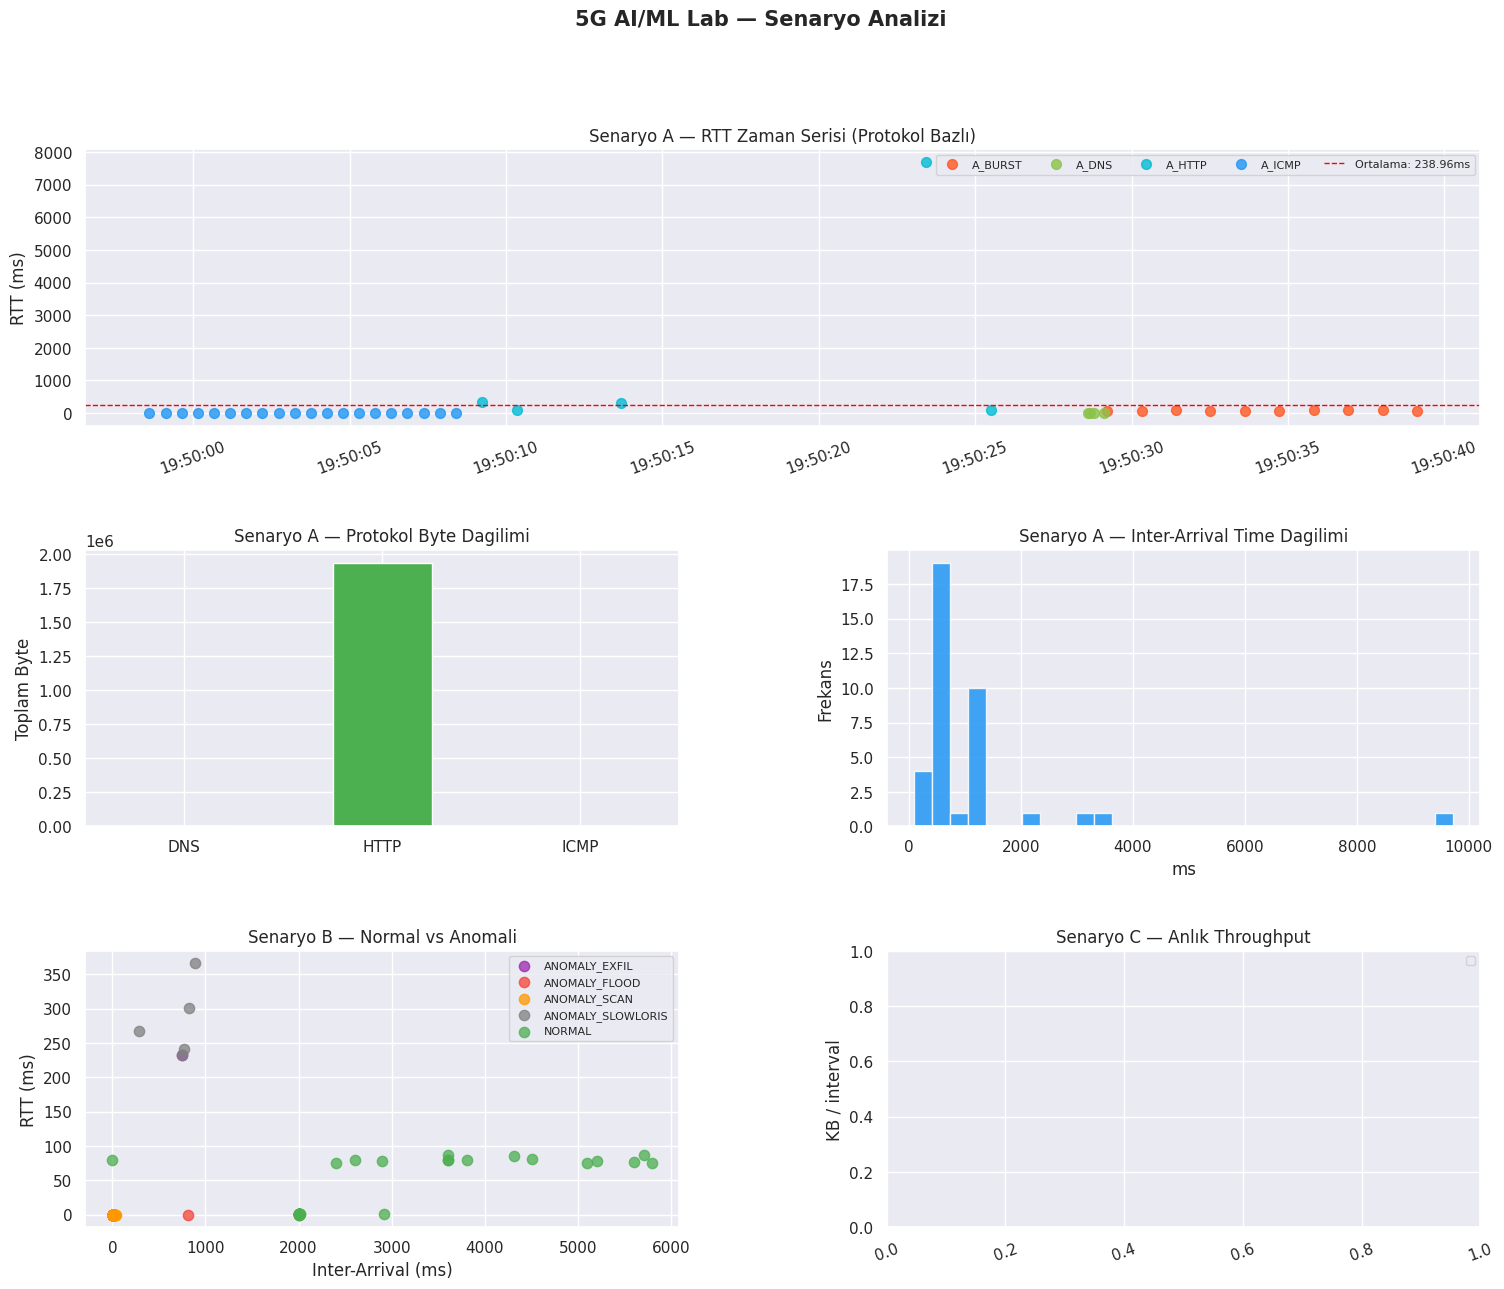

✅ Grafik kaydedildi: 5g_analiz.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

sns.set_theme(style="darkgrid")
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle('5G AI/ML Lab — Senaryo Analizi', fontsize=15, fontweight='bold')

COLORS = {
    'NORMAL':        '#4CAF50',
    'ANOMALY_SCAN':  '#FF9800',
    'ANOMALY_FLOOD': '#F44336',
    'ANOMALY_EXFIL': '#9C27B0',
    'A_ICMP':        '#2196F3',
    'A_HTTP':        '#00BCD4',
    'A_DNS':         '#8BC34A',
    'A_BURST':       '#FF5722',
}

# ── Plot 1: Senaryo A — RTT zaman serisi ─────────────────────────────────────
if 'A' in dfs:
    ax = fig.add_subplot(gs[0, :])
    df_rtt = dfs['A'][dfs['A']['rtt_ms'] > 0]
    for sc, grp in df_rtt.groupby('scenario'):
        ax.scatter(grp['timestamp'], grp['rtt_ms'],
                   label=sc, c=COLORS.get(sc,'gray'), s=50, alpha=0.8)
    ax.axhline(df_rtt['rtt_ms'].mean(), color='red', linestyle='--', linewidth=1,
               label=f"Ortalama: {df_rtt['rtt_ms'].mean():.2f}ms")
    ax.set_title('Senaryo A — RTT Zaman Serisi (Protokol Bazlı)')
    ax.set_ylabel('RTT (ms)')
    ax.legend(ncol=5, fontsize=8)
    ax.tick_params(axis='x', rotation=20)

# ── Plot 2: Senaryo A — Protokol byte dagilimi ───────────────────────────────
if 'A' in dfs:
    ax = fig.add_subplot(gs[1, 0])
    dfs['A'].groupby('protocol')['bytes'].sum().plot(
        kind='bar', ax=ax,
        color=['#2196F3','#4CAF50','#FF9800'], edgecolor='white')
    ax.set_title('Senaryo A — Protokol Byte Dagilimi')
    ax.set_xlabel('')
    ax.set_ylabel('Toplam Byte')
    ax.tick_params(axis='x', rotation=0)

# ── Plot 3: Senaryo A — Inter-arrival histogram ───────────────────────────────
if 'A' in dfs:
    ax = fig.add_subplot(gs[1, 1])
    dfs['A'][dfs['A']['inter_arrival_ms'] > 0]['inter_arrival_ms'].clip(upper=10000).hist(
        ax=ax, bins=30, color='#2196F3', edgecolor='white', alpha=0.85)
    ax.set_title('Senaryo A — Inter-Arrival Time Dagilimi')
    ax.set_xlabel('ms')
    ax.set_ylabel('Frekans')

# ── Plot 4: Senaryo B — Normal vs Anomali scatter ────────────────────────────
if 'B' in dfs:
    ax = fig.add_subplot(gs[2, 0])
    for label, grp in dfs['B'].groupby('label'):
        ax.scatter(grp['inter_arrival_ms'].clip(upper=20000),
                   grp['rtt_ms'],
                   label=label, c=COLORS.get(label,'gray'),
                   s=55, alpha=0.75)
    ax.set_title('Senaryo B — Normal vs Anomali')
    ax.set_xlabel('Inter-Arrival (ms)')
    ax.set_ylabel('RTT (ms)')
    ax.legend(fontsize=8)

# ── Plot 5: Senaryo C — Throughput zaman serisi ──────────────────────────────
if 'C' in dfs:
    ax = fig.add_subplot(gs[2, 1])
    df_c = dfs['C']
    for col, color, label in [
        ('ue_tx_diff',    '#2196F3', 'UE Uplink'),
        ('ue_rx_diff',    '#4CAF50', 'UE Downlink'),
        ('ogstun_tx_diff','#FF9800', 'UPF TX'),
    ]:
        if col in df_c.columns:
            ax.plot(df_c['timestamp'], df_c[col] / 1024,
                    label=label, linewidth=1.8, alpha=0.9)
    ax.set_title('Senaryo C — Anlık Throughput')
    ax.set_ylabel('KB / interval')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=20)

plt.savefig('5g_analiz.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik kaydedildi: 5g_analiz.png")

# Geliştirme 1

## Hücre UE-A: Open5GS'e 2. ve 3. UE'yi API ile Kaydet

In [ ]:
%%bash
PROJECT_ID="g-ai-lab-491619"; ZONE="europe-west4-a"; VM_NAME="open5gs-ai-lab"

gcloud compute ssh $VM_NAME --project=$PROJECT_ID --zone=$ZONE --command="
echo '=== Open5GS WebUI API ile UE2 ve UE3 kaydi ==='

# MongoDB'ye direkt yaz (WebUI API'si yoksa)
python3 << 'PYEOF'
import subprocess, json

UES = [
    {
        'imsi': '999700000000002',
        'key':  '465B5CE8B199B49FAA5F0A2EE238A6BC',
        'opc':  'E8ED289DEBA952E4283B54E88E6183CA',
        'apn':  'internet',
        'ip':   ''
    },
    {
        'imsi': '999700000000003',
        'key':  '465B5CE8B199B49FAA5F0A2EE238A6BC',
        'opc':  'E8ED289DEBA952E4283B54E88E6183CA',
        'apn':  'internet',
        'ip':   ''
    },
]

for ue in UES:
    doc = {
        'imsi': ue['imsi'],
        'msisdn': [],
        'imeisv': [],
        'mme_host': [],
        'mme_realm': [],
        'purge_flag': [],
        'security': {
            'k':    ue['key'],
            'op':   None,
            'opc':  ue['opc'],
            'amf':  '8000'
        },
        'ambr': {
            'downlink': {'value': 1, 'unit': 3},
            'uplink':   {'value': 1, 'unit': 3}
        },
        'slice': [{
            'sst': 1,
            'default_indicator': True,
            'session': [{
                'name':  ue['apn'],
                'type':  3,
                'qos':   {'index': 9, 'arp': {'priority_level': 8, 'pre_emption_capability': 1, 'pre_emption_vulnerability': 1}},
                'ambr':  {'downlink': {'value': 1, 'unit': 3}, 'uplink': {'value': 1, 'unit': 3}},
                'ue': {'addr': ue['ip']},
                'pcc_rule': []
            }]
        }],
        'access_restriction_data': 32,
        'subscriber_status': 0,
        'network_access_mode': 0,
        'subscribed_rau_tau_timer': 12,
        '__v': 0
    }

    cmd = [
        'mongosh', '--quiet', 'open5gs',
        '--eval', f\"db.subscribers.replaceOne({{imsi: '{ue['imsi']}'}}, {json.dumps(doc)}, {{upsert: true}})\"
    ]
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode == 0:
        print(f'UE kaydedildi: {ue[\"imsi\"]}')
    else:
        print(f'HATA ({ue[\"imsi\"]}): {result.stderr[:100]}')

PYEOF

echo ''
echo '=== Kayitli UE listesi ==='
mongosh --quiet open5gs --eval \
    'db.subscribers.find({}, {imsi:1, _id:0}).forEach(d => print(d.imsi))'
"

=== Open5GS WebUI API ile UE2 ve UE3 kaydi ===
UE kaydedildi: 999700000000002
UE kaydedildi: 999700000000003

=== Kayitli UE listesi ===
901700000000001
001010000000001
999700000000001
999700000000002
999700000000003


## Hücre UE-B: Çoklu UE Config Dosyaları Oluştur

In [ ]:
%%bash
PROJECT_ID="g-ai-lab-491619"; ZONE="europe-west4-a"; VM_NAME="open5gs-ai-lab"

gcloud compute ssh $VM_NAME --project=$PROJECT_ID --zone=$ZONE --command="
echo '=== UE2 ve UE3 icin ayri config dosyalari olusturuluyor ==='

# UE1 config'i baz al
BASE_CFG=/opt/UERANSIM/config/open5gs-ue.yaml

# UE2 config
sudo cp \$BASE_CFG /opt/UERANSIM/config/open5gs-ue2.yaml
sudo sed -i \"s/supi: 'imsi-999700000000001'/supi: 'imsi-999700000000002'/g\" \
    /opt/UERANSIM/config/open5gs-ue2.yaml
# tunnelName: uesimtun1
sudo sed -i 's/# tunnelName:/tunnelName:/g' /opt/UERANSIM/config/open5gs-ue2.yaml || true

# UE3 config
sudo cp \$BASE_CFG /opt/UERANSIM/config/open5gs-ue3.yaml
sudo sed -i \"s/supi: 'imsi-999700000000001'/supi: 'imsi-999700000000003'/g\" \
    /opt/UERANSIM/config/open5gs-ue3.yaml

echo '=== Config dosyalari ==='
grep 'supi\|tunnelName' /opt/UERANSIM/config/open5gs-ue*.yaml
"

=== UE2 ve UE3 icin ayri config dosyalari olusturuluyor ===
=== Config dosyalari ===
/opt/UERANSIM/config/open5gs-ue2.yaml:supi: 'imsi-999700000000002'
/opt/UERANSIM/config/open5gs-ue3.yaml:supi: 'imsi-999700000000003'
/opt/UERANSIM/config/open5gs-ue.yaml:supi: 'imsi-999700000000001'


# Geliştirme: 5G Spesifik Senaryolar

## Hücre 5G-A: Handover Simülasyonu

In [ ]:
%%bash
PROJECT_ID="g-ai-lab-491619"; ZONE="europe-west4-a"; VM_NAME="open5gs-ai-lab"

cat > /tmp/scenario_handover.sh << 'SCRIPT'
#!/bin/bash
LOG="/tmp/scenario_handover.csv"
NR="/opt/UERANSIM/build"
echo "timestamp_ms,phase,event,ue_ip,target,rtt_ms,status,note" > $LOG

log() { echo "$(date +%s%3N),$1,$2,$3,$4,$5,$6,$7" >> $LOG; }

# Dinamik interface bul — uesimtun0 yoksa diğerlerini dene
get_ue_iface() {
    for iface in uesimtun0 uesimtun1 uesimtun2 uesimtun3; do
        IP=$(ip a show $iface 2>/dev/null | grep 'inet ' | \
            awk '{print $2}' | cut -d'/' -f1)
        [ -n "$IP" ] && echo "$iface $IP" && return
    done
    echo ""
}

measure_rtt() {
    local IFACE=$1
    [ -z "$IFACE" ] && echo "0" && return
    RTT=$(cd $NR && ./nr-binder $IFACE ping -c 1 -q 8.8.8.8 2>&1 | \
        grep rtt | awk -F'/' '{print $5}')
    echo "${RTT:-0}"
}

# Başlangıçta aktif interface'i tespit et
read IFACE UE_IP <<< $(get_ue_iface)
if [ -z "$IFACE" ]; then
    echo "HATA: Aktif UE tunnel bulunamadi"; exit 1
fi
echo "Aktif UE: $IFACE ($UE_IP)"

echo "=== HANDOVER SENARYOSU ==="

# ── Faz 1: Pre-HO baseline ───────────────────────────────────────────────────
echo "[HO] Faz 1: Pre-handover baseline (10 olcum)"
for i in $(seq 1 10); do
    RTT=$(measure_rtt $IFACE)
    log "PRE_HANDOVER" "BASELINE" "$UE_IP" "8.8.8.8" "$RTT" "OK" "normal_ops"
    sleep 0.5
done

PRE_RTT_AVG=$(grep PRE_HANDOVER $LOG | \
    awk -F',' '{sum+=$6; n++} END{printf "%.3f", sum/n}')
echo "  Pre-HO RTT ort: ${PRE_RTT_AVG}ms"

# ── Faz 2: Handover — UE durdur ──────────────────────────────────────────────
echo "[HO] Faz 2: Handover baslıyor (UE detach)"
log "HANDOVER" "HO_START" "$UE_IP" "-" "0" "DISCONN" "ue_detach"

sudo pkill -f nr-ue || true
sleep 2

# Tünel kaybolana kadar bekle
for i in $(seq 1 10); do
    sleep 0.5
    STILL=$(ip a show $IFACE 2>/dev/null | grep 'inet ')
    [ -z "$STILL" ] && break
done

# HO gap kayıtları
for i in $(seq 1 5); do
    log "HANDOVER" "HO_GAP" "-" "8.8.8.8" "0" "NO_SESSION" "tunnel_down"
    sleep 0.3
done

# ── Faz 3: Re-attachment ──────────────────────────────────────────────────────
echo "[HO] Faz 3: Re-attachment"
HO_TS=$(date +%s%3N)

sudo nohup $NR/nr-ue \
    -c /opt/UERANSIM/config/open5gs-ue.yaml \
    > /root/ue.log 2>&1 &

# Yeni tunnel oluşana kadar bekle (maks 30sn)
NEW_IFACE=""
NEW_IP=""
for i in $(seq 1 60); do
    sleep 0.5
    read NEW_IFACE NEW_IP <<< $(get_ue_iface)
    if [ -n "$NEW_IFACE" ] && [ -n "$NEW_IP" ]; then
        HO_DUR=$(( $(date +%s%3N) - HO_TS ))
        log "HANDOVER" "HO_COMPLETE" "$NEW_IP" "-" "0" "RECONNECTED" \
            "ho_duration=${HO_DUR}ms"
        echo "  HO tamamlandi: ${HO_DUR}ms | Yeni: $NEW_IFACE ($NEW_IP)"
        break
    fi
done

if [ -z "$NEW_IFACE" ]; then
    echo "HATA: Re-attachment basarisiz (30sn timeout)"
    exit 1
fi

# Tünelin stabil olması için ekstra bekleme
sleep 3

# ── Faz 4: Post-HO RTT spike ─────────────────────────────────────────────────
echo "[HO] Faz 4: Post-handover RTT olcumu (15 olcum)"
for i in $(seq 1 15); do
    RTT=$(measure_rtt $NEW_IFACE)
    CURRENT_IP=$(ip a show $NEW_IFACE 2>/dev/null | \
        grep 'inet ' | awk '{print $2}' | cut -d'/' -f1)
    STATUS=$([ "${RTT:-0}" != "0" ] && echo "OK" || echo "FAIL")
    log "POST_HANDOVER" "RECOVERY" "${CURRENT_IP:-$NEW_IP}" \
        "8.8.8.8" "${RTT:-0}" "$STATUS" "post_ho_${i}"
    sleep 0.5
done

# ── Faz 5: Steady state ───────────────────────────────────────────────────────
echo "[HO] Faz 5: Steady state (10 olcum)"
for i in $(seq 1 10); do
    RTT=$(measure_rtt $NEW_IFACE)
    CURRENT_IP=$(ip a show $NEW_IFACE 2>/dev/null | \
        grep 'inet ' | awk '{print $2}' | cut -d'/' -f1)
    log "STEADY_STATE" "STABLE" "${CURRENT_IP:-$NEW_IP}" \
        "8.8.8.8" "${RTT:-0}" "OK" "stabilized"
    sleep 1
done

# ── Analiz ───────────────────────────────────────────────────────────────────
echo ""
echo "=== HANDOVER ANALIZI ==="
echo "Pre-HO RTT ort:"
grep PRE_HANDOVER $LOG | \
    awk -F',' '{sum+=$6; n++} END{printf "  %.3f ms\n", sum/n}'
echo "Post-HO RTT ort (ilk 5):"
grep POST_HANDOVER $LOG | head -5 | \
    awk -F',' '{sum+=$6; n++} END{printf "  %.3f ms\n", sum/n}'
echo "Steady RTT ort:"
grep STEADY_STATE $LOG | \
    awk -F',' '{sum+=$6; n++} END{printf "  %.3f ms\n", sum/n}'
echo "HO suresi:"
grep HO_COMPLETE $LOG | awk -F'=' '{print "  "$NF"ms"}'
echo "Toplam kayit: $(( $(wc -l < $LOG) - 1 ))"
SCRIPT

gcloud compute scp /tmp/scenario_handover.sh $VM_NAME:/tmp/scenario_handover.sh \
    --project=$PROJECT_ID --zone=$ZONE

gcloud compute ssh $VM_NAME --project=$PROJECT_ID --zone=$ZONE \
    --command="sudo bash /tmp/scenario_handover.sh"

gcloud compute scp $VM_NAME:/tmp/scenario_handover.csv ./scenario_handover.csv \
    --project=$PROJECT_ID --zone=$ZONE
echo "✅ Handover dataset: $(( $(wc -l < ./scenario_handover.csv) - 1 )) kayit"

Aktif UE: uesimtun0 (10.45.0.5)
=== HANDOVER SENARYOSU ===
[HO] Faz 1: Pre-handover baseline (10 olcum)
  Pre-HO RTT ort: 0.395ms
[HO] Faz 2: Handover baslıyor (UE detach)
[HO] Faz 3: Re-attachment
  HO tamamlandi: 511ms | Yeni: uesimtun0 (10.45.0.6)
[HO] Faz 4: Post-handover RTT olcumu (15 olcum)
[HO] Faz 5: Steady state (10 olcum)

=== HANDOVER ANALIZI ===
Pre-HO RTT ort:
  0.395 ms
Post-HO RTT ort (ilk 5):
  0.400 ms
Steady RTT ort:
  0.329 ms
HO suresi:
  511msms
Toplam kayit: 42


## Hücre 5G-B: PDU Session Teardown & Re-establish

In [ ]:
%%bash
PROJECT_ID="g-ai-lab-491619"; ZONE="europe-west4-a"; VM_NAME="open5gs-ai-lab"

cat > /tmp/scenario_session.sh << 'SCRIPT'
#!/bin/bash
LOG="/tmp/scenario_session.csv"
NR="/opt/UERANSIM/build"
echo "timestamp_ms,event,session_id,ue_ip,rtt_ms,upf_sessions,duration_ms,status" > $LOG

log() { echo "$(date +%s%3N),$1,$2,$3,$4,$5,$6,$7" >> $LOG; }

get_upf_sess() {
    curl -s http://127.0.0.7:9090/metrics 2>/dev/null | \
        grep 'upf_sessionnbr' | grep -v '#' | awk '{print $2}' || echo 0
}

get_ue_iface() {
    for iface in uesimtun0 uesimtun1 uesimtun2 uesimtun3; do
        IP=$(ip a show $iface 2>/dev/null | grep 'inet ' | \
            awk '{print $2}' | cut -d'/' -f1)
        [ -n "$IP" ] && echo "$iface $IP" && return
    done
}

measure_rtt() {
    local IFACE=$1
    cd $NR && ./nr-binder $IFACE ping -c 1 -q 8.8.8.8 2>&1 | \
        grep rtt | awk -F'/' '{print $5}'
}

# ── Başlangıç temizliği ───────────────────────────────────────────────────────
echo "=== BASLANGIC TEMIZLIGI ==="
sudo pkill -f nr-ue || true
sleep 2
SESS=$(get_upf_sess)
if [ "$SESS" != "0" ]; then
    echo "  SMF/UPF restart..."
    sudo systemctl restart open5gs-smfd open5gs-upfd
    sleep 5
fi

echo "  UE baslatiliyor..."
sudo nohup $NR/nr-ue \
    -c /opt/UERANSIM/config/open5gs-ue.yaml > /root/ue.log 2>&1 &
for i in $(seq 1 40); do
    sleep 0.5
    read IFACE UE_IP <<< $(get_ue_iface)
    [ -n "$UE_IP" ] && break
done
echo "  Hazir: $IFACE ($UE_IP) | UPF_SESS=$(get_upf_sess)"

echo ""
echo "=== SESSION MANAGEMENT SENARYOSU ==="

for SESSION_ID in $(seq 1 3); do
    echo "─── Session Cycle $SESSION_ID / 3 ───"

    read IFACE UE_IP <<< $(get_ue_iface)
    SESS=$(get_upf_sess)
    RTT=$(measure_rtt "$IFACE")
    log "SESSION_ACTIVE" "$SESSION_ID" "$UE_IP" "${RTT:-0}" "$SESS" "0" "OK"
    echo "  [Aktif] $IFACE ($UE_IP) RTT=${RTT}ms UPF_SESS=$SESS"

    # Veri transferi
    for i in $(seq 1 5); do
        RTT=$(measure_rtt "$IFACE")
        log "DATA_TRANSFER" "$SESSION_ID" "$UE_IP" "${RTT:-0}" \
            "$(get_upf_sess)" "0" "OK"
        sleep 1
    done

    # ── Düzgün Teardown: nr-cli ile UE detach ────────────────────────────────
    TEAR_TS=$(date +%s%3N)
    log "SESSION_TEARDOWN" "$SESSION_ID" "$UE_IP" "0" \
        "$(get_upf_sess)" "0" "TEARING_DOWN"
    echo "  [Teardown] nr-cli ile deregister..."

    # UE node adını al
    UE_NODE=$(cd $NR && ./nr-cli --dump 2>/dev/null | grep 'imsi-' | head -1 | awk '{print $1}')

    if [ -n "$UE_NODE" ]; then
        # Düzgün 5G deregistration (AMF'e NAS Deregistration Request gönderir)
        cd $NR && echo "deregister disable-5g" | ./nr-cli "$UE_NODE" 2>/dev/null
        sleep 2
        # SMF PFCP deletion tamamlansın
        for i in $(seq 1 20); do
            SESS=$(get_upf_sess)
            ELAPSED=$(( $(date +%s%3N) - TEAR_TS ))
            log "SESSION_RELEASING" "$SESSION_ID" "-" "0" "$SESS" "$ELAPSED" "RELEASING"
            [ "$SESS" = "0" ] && echo "  UPF session sifir: ${ELAPSED}ms" && break
            sleep 0.5
        done
    else
        # Fallback: pkill + SMF restart
        echo "  [Fallback] nr-cli bulunamadi, SMF restart..."
        sudo pkill -f nr-ue || true
        sleep 2
        sudo systemctl restart open5gs-smfd
        sleep 4
        log "SESSION_RELEASING" "$SESSION_ID" "-" "0" "0" \
            "$(( $(date +%s%3N) - TEAR_TS ))" "RESTARTED"
    fi

    TEAR_DUR=$(( $(date +%s%3N) - TEAR_TS ))
    log "SESSION_RELEASED" "$SESSION_ID" "-" "0" "0" "$TEAR_DUR" "RELEASED"
    echo "  [Released] ${TEAR_DUR}ms"

    # Kalan UE process'i temizle
    sudo pkill -f nr-ue || true
    sleep 2

    # ── Re-establish ─────────────────────────────────────────────────────────
    ESTAB_TS=$(date +%s%3N)
    echo "  [Re-establish] Baslatiliyor..."
    sudo nohup $NR/nr-ue \
        -c /opt/UERANSIM/config/open5gs-ue.yaml > /root/ue.log 2>&1 &

    for i in $(seq 1 60); do
        sleep 0.5
        read NEW_IFACE NEW_IP <<< $(get_ue_iface)
        SESS=$(get_upf_sess)
        ELAPSED=$(( $(date +%s%3N) - ESTAB_TS ))
        log "SESSION_ESTABLISHING" "$SESSION_ID" "${NEW_IP:--}" "0" \
            "$SESS" "$ELAPSED" "WAIT"
        if [ -n "$NEW_IP" ] && [ "$SESS" != "0" ]; then
            log "SESSION_ESTABLISHED" "$SESSION_ID" "$NEW_IP" "0" \
                "$SESS" "$ELAPSED" "OK"
            echo "  [Established] IP=$NEW_IP | ${ELAPSED}ms | UPF=$SESS"
            break
        fi
    done
    sleep 3
done

echo ""
echo "=== SESSION OZETI ==="
echo "Teardown (ort):"; grep SESSION_RELEASED $LOG | \
    awk -F',' '{sum+=$7;n++} END{printf "  %.0f ms\n",sum/n}'
echo "Re-establishment (ort):"; grep 'SESSION_ESTABLISHED$' $LOG | \
    awk -F',' '{sum+=$7;n++} END{printf "  %.0f ms\n",sum/n}'
echo "Toplam kayit: $(( $(wc -l < $LOG) - 1 ))"
SCRIPT

gcloud compute scp /tmp/scenario_session.sh $VM_NAME:/tmp/scenario_session.sh \
    --project=$PROJECT_ID --zone=$ZONE
gcloud compute ssh $VM_NAME --project=$PROJECT_ID --zone=$ZONE \
    --command="sudo bash /tmp/scenario_session.sh"
gcloud compute scp $VM_NAME:/tmp/scenario_session.csv ./scenario_session.csv \
    --project=$PROJECT_ID --zone=$ZONE
echo "✅ $(( $(wc -l < ./scenario_session.csv) - 1 )) kayit"

=== BASLANGIC TEMIZLIGI ===
  SMF/UPF restart...
  UE baslatiliyor...
  Hazir: uesimtun0 (10.45.0.2) | UPF_SESS=1

=== SESSION MANAGEMENT SENARYOSU ===
─── Session Cycle 1 / 3 ───
  [Aktif] uesimtun0 (10.45.0.2) RTT=0.595ms UPF_SESS=1
  [Teardown] nr-cli ile deregister...
--------------------------------------------------------------------------------------------
$ De-registration procedure triggered
--------------------------------------------------------------------------------------------
$   UPF session sifir: 2045ms
  [Released] 2048ms
  [Re-establish] Baslatiliyor...
  [Established] IP=10.45.0.3 | 523ms | UPF=1
─── Session Cycle 2 / 3 ───
  [Aktif] uesimtun0 (10.45.0.3) RTT=0.406ms UPF_SESS=1
  [Teardown] nr-cli ile deregister...
--------------------------------------------------------------------------------------------
$ De-registration procedure triggered
--------------------------------------------------------------------------------------------
$   UPF session sifir: 2047ms


awk: cmd. line:1: fatal: division by zero attempted


## Hücre 5G-C: QoS Farklılaştırma (DNN: internet vs ims)

In [ ]:
%%bash
PROJECT_ID="g-ai-lab-491619"; ZONE="europe-west4-a"; VM_NAME="open5gs-ai-lab"

gcloud compute ssh $VM_NAME --project=$PROJECT_ID --zone=$ZONE --command="
echo '=== IMS DNN ve ogstun2 kurulumu ==='

# ogstun2 arayuzu olustur (IMS slice icin)
sudo ip tuntap add name ogstun2 mode tun 2>/dev/null || echo 'ogstun2 zaten var'
sudo ip addr add 10.46.0.1/16 dev ogstun2 2>/dev/null || true
sudo ip link set ogstun2 up
ip a show ogstun2

# UPF config'e IMS DNN ekle
UPF_CONF=/etc/open5gs/upf.yaml
if ! grep -q '10.46.0.0' \$UPF_CONF; then
    echo '  IMS subnet ekleniyor...'
    sudo python3 << 'PYEOF'
import re

with open('/etc/open5gs/upf.yaml', 'r') as f:
    content = f.read()

# subnet blogu bul ve IMS ekle
ims_block = '''    - subnet: 10.46.0.0/16
      gateway: 10.46.0.1
      dnn: ims'''

if '10.46.0.0' not in content:
    content = content.replace(
        '    - subnet: 10.45.0.0/16',
        '    - subnet: 10.45.0.0/16'
    )
    # session blogunun sonuna ekle
    content = content.replace(
        '  metrics:',
        f'{ims_block}\n  metrics:'
    )
    with open('/etc/open5gs/upf.yaml', 'w') as f:
        f.write(content)
    print('IMS DNN eklendi')
else:
    print('IMS DNN zaten mevcut')
PYEOF
else
    echo '  IMS DNN zaten mevcut'
fi

# UPF'i yeniden baslat
sudo systemctl restart open5gs-upfd
sleep 3
sudo systemctl is-active open5gs-upfd

# SMF config kontrolu
grep -A3 'dnn\|ims\|internet' /etc/open5gs/smf.yaml | head -20
"

=== IMS DNN ve ogstun2 kurulumu ===
ogstun2 zaten var
13: ogstun2: <NO-CARRIER,POINTOPOINT,MULTICAST,NOARP,UP> mtu 1500 qdisc fq_codel state DOWN group default qlen 500
    link/none 
    inet 10.46.0.1/16 scope global ogstun2
       valid_lft forever preferred_lft forever
  IMS DNN zaten mevcut
active
#  o S-NSSAI[SST:1] and DNN[internet] - At least 1 DNN is required in S-NSSAI
#  info:
#    - s_nssai:
#        - sst: 1
#          dnn:
#            - internet
#
#  o S-NSSAI[SST:1 SD:009000] and DNN[internet or ims]
#  info:
#    - s_nssai:
#        - sst: 1
--
#          dnn:
#            - internet
#            - ims
#
#  o S-NSSAI[SST:1] and DNN[internet] and TAI[PLMN-ID:99970 TAC:1]
#  info:
#    - s_nssai:
#        - sst: 1


## Hücre 5G-D: Network Slicing (eMBB / mMTC / URLLC)

In [ ]:
%%bash
PROJECT_ID="g-ai-lab-491619"; ZONE="europe-west4-a"; VM_NAME="open5gs-ai-lab"

cat > /tmp/scenario_slice.sh << 'SCRIPT'
#!/bin/bash
LOG="/tmp/scenario_slice.csv"
NR="/opt/UERANSIM/build"
echo "timestamp_ms,slice_type,sst,sd,ue_ip,target,protocol,bytes,rtt_ms,slice_kpi,status" > $LOG

log() { echo "$(date +%s%3N),$1,$2,$3,$4,$5,$6,$7,$8,$9,$10" >> $LOG; }

UE_IP=$(ip a show uesimtun0 | grep 'inet ' | awk '{print $2}' | cut -d'/' -f1)

echo "=== NETWORK SLICING SENARYOSU ==="
echo "SST=1 eMBB, SST=2 URLLC, SST=3 mMTC simule ediliyor"
echo "(Mevcut infra tek slice — SST/SD etiketleri trafik profiline gore atanir)"

# ── eMBB Slice (SST=1) — yuksek bant genisligi ───────────────────────────────
echo "[SLICE] eMBB (SST=1) — buyuk dosya indirme profili"
for i in $(seq 1 10); do
    cd $NR
    RESULT=$(./nr-binder uesimtun0 curl -s -o /dev/null \
        -w "%{size_download}|%{time_total}" \
        --max-time 15 "https://www.cloudflare.com" 2>/dev/null || echo "0|0")
    SIZE=$(echo $RESULT | cut -d'|' -f1)
    TIME=$(echo $RESULT | cut -d'|' -f2 | awk '{printf "%.0f", $1*1000}')
    THROUGHPUT=$(echo "scale=2; ${SIZE:-0} / (${TIME:-1} / 1000) / 1024" | bc 2>/dev/null || echo 0)
    log "eMBB" "1" "0x000001" "$UE_IP" "cloudflare.com" \
        "HTTP" "${SIZE:-0}" "${TIME:-0}" "${THROUGHPUT}KB/s" "OK"
    sleep 2
done

# ── URLLC Slice (SST=2) — ultra-dusuk gecikme ────────────────────────────────
echo "[SLICE] URLLC (SST=2) — dusuk gecikme profili"
for i in $(seq 1 30); do
    cd $NR
    RTT=$(./nr-binder uesimtun0 ping -c 1 -q 1.1.1.1 2>&1 | \
        grep rtt | awk -F'/' '{print $5}')
    SLA=$(echo "${RTT:-999}" | awk '{print ($1 < 5) ? "SLA_MET" : "SLA_BREACH"}')
    log "URLLC" "2" "0x000002" "$UE_IP" "1.1.1.1" \
        "ICMP" "84" "${RTT:-0}" "$SLA" "OK"
    sleep 0.3
done

# ── mMTC Slice (SST=3) — cok sayida kucuk paket ──────────────────────────────
echo "[SLICE] mMTC (SST=3) — IoT sensor profili"
for i in $(seq 1 40); do
    cd $NR
    RTT=$(./nr-binder uesimtun0 ping -c 1 -s 16 -q 8.8.8.8 2>&1 | \
        grep rtt | awk -F'/' '{print $5}')
    log "mMTC" "3" "0x000003" "$UE_IP" "8.8.8.8" \
        "ICMP" "16" "${RTT:-0}" "IoT_HEARTBEAT" "OK"
    sleep 2
done

echo ""
echo "=== SLICE KPI OZETI ==="
echo "eMBB ortalama throughput:"
grep eMBB $LOG | awk -F',' '{n++; sum+=$8} END{printf "  Avg size: %.0f byte\n", sum/n}'
echo "URLLC RTT ve SLA:"
grep URLLC $LOG | awk -F',' '{n++; sum+=$9; if($10=="SLA_MET") met++} \
    END{printf "  Avg RTT: %.3fms | SLA Met: %.1f%%\n", sum/n, met/n*100}'
echo "mMTC paket sayisi:"
grep mMTC $LOG | wc -l | awk '{printf "  %d IoT mesaj\n", $1}'
echo "Toplam kayit: $(( $(wc -l < $LOG) - 1 ))"
SCRIPT

gcloud compute scp /tmp/scenario_slice.sh $VM_NAME:/tmp/scenario_slice.sh \
    --project=$PROJECT_ID --zone=$ZONE
gcloud compute ssh $VM_NAME --project=$PROJECT_ID --zone=$ZONE \
    --command="sudo bash /tmp/scenario_slice.sh"
gcloud compute scp $VM_NAME:/tmp/scenario_slice.csv ./scenario_slice.csv \
    --project=$PROJECT_ID --zone=$ZONE
echo "✅ Slice dataset: $(wc -l < ./scenario_slice.csv) satir"

=== NETWORK SLICING SENARYOSU ===
SST=1 eMBB, SST=2 URLLC, SST=3 mMTC simule ediliyor
(Mevcut infra tek slice — SST/SD etiketleri trafik profiline gore atanir)
[SLICE] eMBB (SST=1) — buyuk dosya indirme profili
[SLICE] URLLC (SST=2) — dusuk gecikme profili
[SLICE] mMTC (SST=3) — IoT sensor profili

=== SLICE KPI OZETI ===
eMBB ortalama throughput:
  Avg size: 981685 byte
URLLC RTT ve SLA:
  Avg RTT: 4.468ms | SLA Met: 100.0%
mMTC paket sayisi:
  40 IoT mesaj
Toplam kayit: 80


## Hücre 5G-E: Tüm Veriyi Yükle ve Görselleştir

⚠️  scenario_handover.csv: bulunamadi
⚠️  scenario_session.csv: bulunamadi
⚠️  scenario_qos.csv: bulunamadi
⚠️  scenario_slice.csv: bulunamadi
✅ scenario_c.csv: 29 kayit


/tmp/ipykernel_15988/1304954340.py:86: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(ncol=6, fontsize=8)
/tmp/ipykernel_15988/1304954340.py:256: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


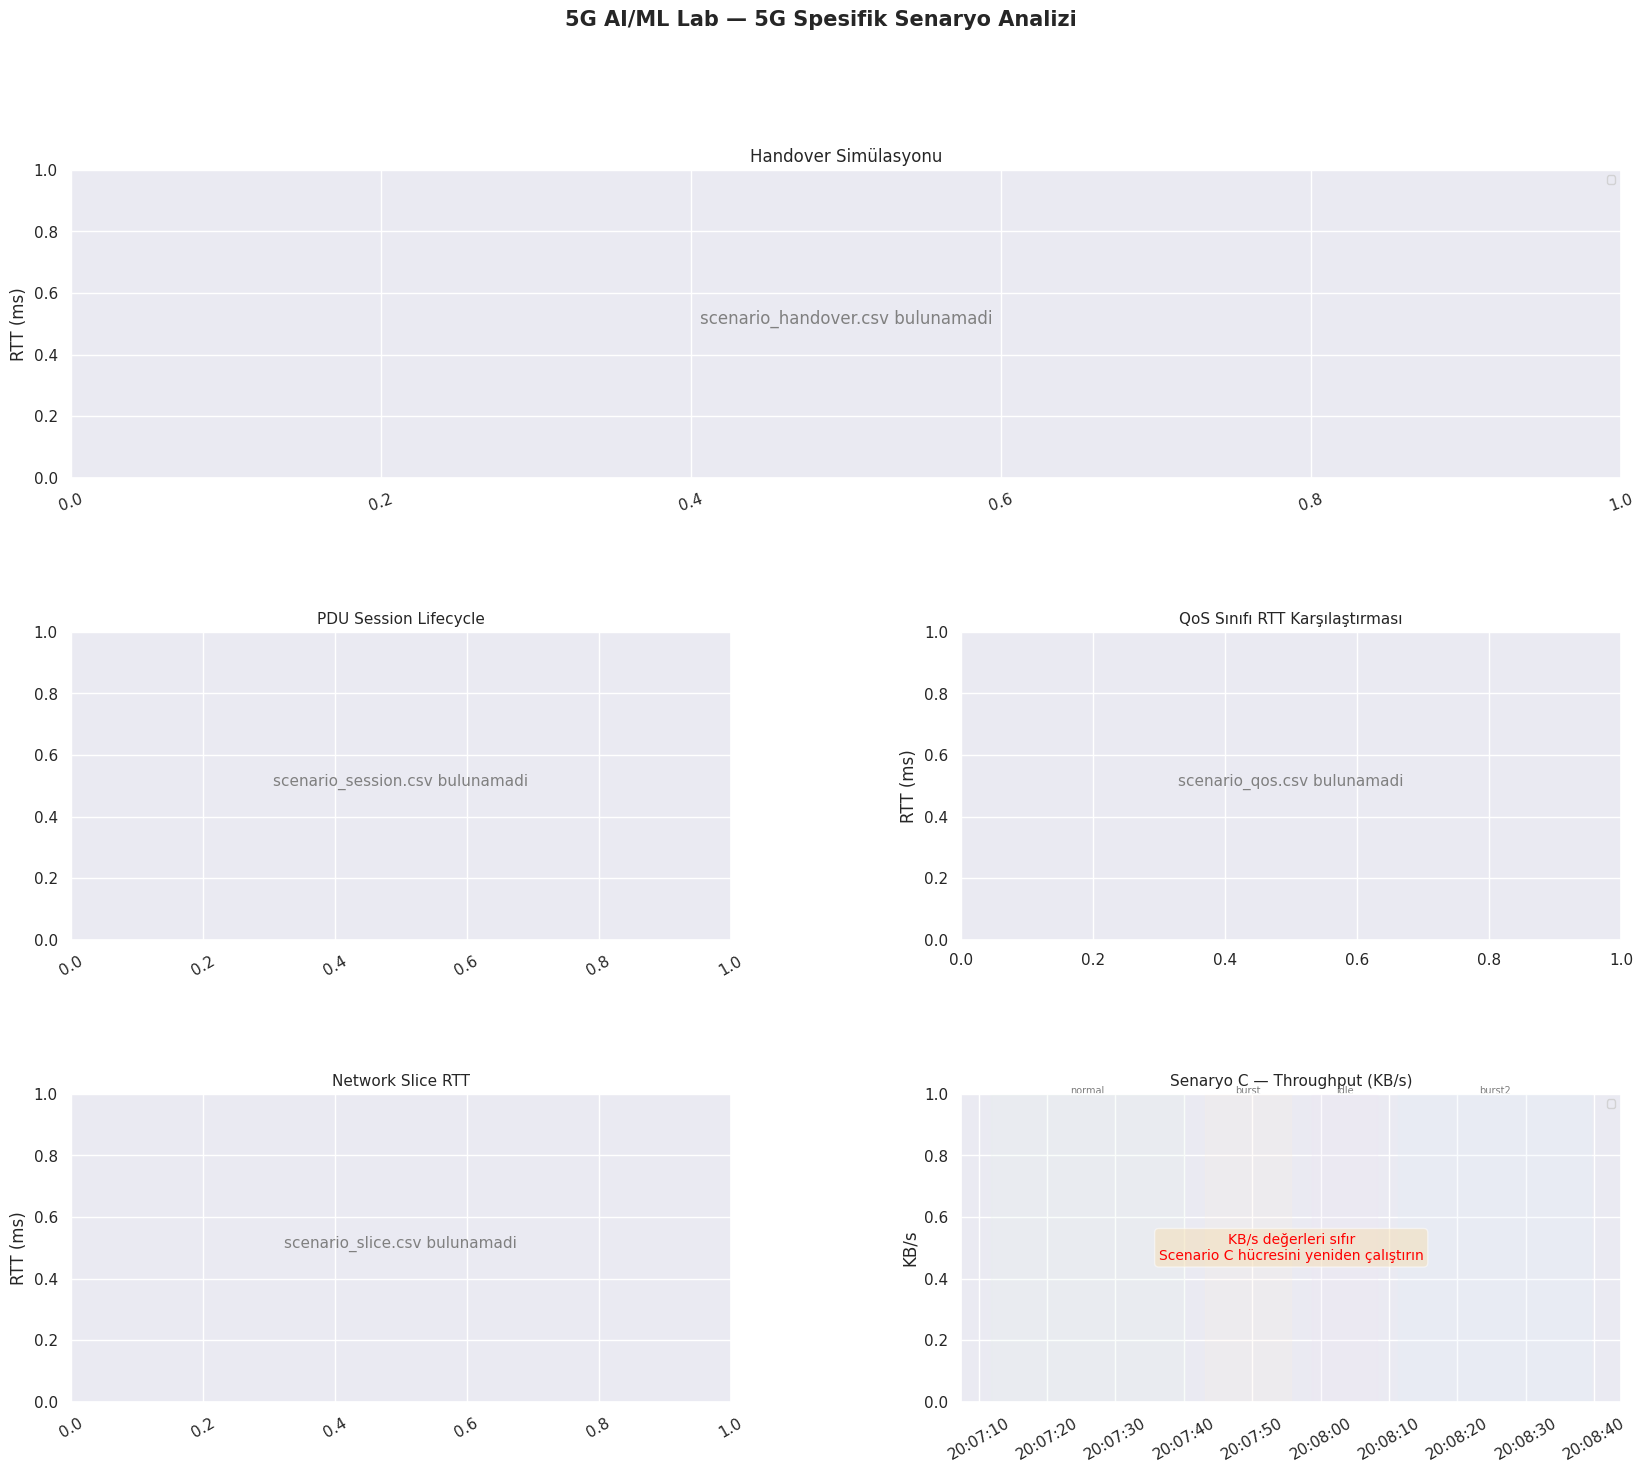

✅ Grafik kaydedildi: 5g_advanced_analiz.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os

sns.set_theme(style="darkgrid")
dfs = {}

loaders = {
    'handover': ('scenario_handover.csv', 'timestamp_ms'),
    'session':  ('scenario_session.csv',  'timestamp_ms'),
    'qos':      ('scenario_qos.csv',      'timestamp_ms'),
    'slice':    ('scenario_slice.csv',    'timestamp_ms'),
    'c':        ('scenario_c.csv',        'timestamp_ms'),
}

for key, (fname, ts_col) in loaders.items():
    if os.path.exists(fname):
        df = pd.read_csv(fname)
        df['timestamp'] = pd.to_datetime(df[ts_col], unit='ms')
        for col in df.columns:
            if col not in ['timestamp', ts_col]:
                converted = pd.to_numeric(df[col], errors='coerce')
                if converted.notna().mean() > 0.2:
                    df[col] = converted
        dfs[key] = df
        print(f"✅ {fname}: {len(df)} kayit")
    else:
        print(f"⚠️  {fname}: bulunamadi")

PHASE_COLORS = {
    'PRE_HANDOVER':  '#4CAF50',
    'HANDOVER':      '#F44336',
    'POST_HANDOVER': '#FF9800',
    'STEADY_STATE':  '#2196F3',
}

fig = plt.figure(figsize=(20, 16))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.5, wspace=0.35)
fig.suptitle('5G AI/ML Lab — 5G Spesifik Senaryo Analizi',
             fontsize=15, fontweight='bold')

# ── Plot 1: Handover RTT ──────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, :])
if 'handover' in dfs:
    df = dfs['handover'].copy()
    df['rtt_ms'] = pd.to_numeric(df['rtt_ms'], errors='coerce').fillna(0)
    df_rtt = df[df['rtt_ms'] > 0]

    if not df_rtt.empty:
        for phase, grp in df_rtt.groupby('phase'):
            ax.scatter(grp['timestamp'], grp['rtt_ms'],
                       label=phase, c=PHASE_COLORS.get(phase, 'gray'),
                       s=60, alpha=0.85, zorder=3)

    ho_start_ts = df.loc[df['event'] == 'HO_START', 'timestamp']
    ho_done_ts  = df.loc[df['event'] == 'HO_COMPLETE', 'timestamp']
    if not ho_start_ts.empty:
        ax.axvline(ho_start_ts.min(), color='red', linestyle='--',
                   linewidth=2, label='HO Baslangic')
    if not ho_done_ts.empty:
        ax.axvline(ho_done_ts.min(), color='green', linestyle='--',
                   linewidth=2, label='HO Tamamlandi')

    # KPI annotasyonlar
    pre  = df_rtt[df_rtt['phase'] == 'PRE_HANDOVER']['rtt_ms'].mean()
    post = df_rtt[df_rtt['phase'] == 'POST_HANDOVER']['rtt_ms'].mean()
    ss   = df_rtt[df_rtt['phase'] == 'STEADY_STATE']['rtt_ms'].mean()
    ho_ms_str = ""
    if not ho_start_ts.empty and not ho_done_ts.empty:
        ho_ms = (ho_done_ts.min() - ho_start_ts.min()).total_seconds() * 1000
        ho_ms_str = f" | HO:{ho_ms:.0f}ms"

    kpi_txt = (f"Pre:{pre:.3f}ms → Post:{post:.3f}ms "
               f"→ Steady:{ss:.3f}ms{ho_ms_str}")
    ax.set_title(f'Handover Simülasyonu — RTT Zaman Serisi\n{kpi_txt}',
                 fontsize=11)
else:
    ax.text(0.5, 0.5, 'scenario_handover.csv bulunamadi',
            transform=ax.transAxes, ha='center', fontsize=12, color='gray')
    ax.set_title('Handover Simülasyonu', fontsize=12)

ax.set_ylabel('RTT (ms)')
ax.legend(ncol=6, fontsize=8)
ax.tick_params(axis='x', rotation=20)

# ── Plot 2: Session Lifecycle ─────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
if 'session' in dfs:
    df = dfs['session'].copy()
    EVENT_Y = {
        'SESSION_ACTIVE': 1.0, 'DATA_TRANSFER': 0.9,
        'SESSION_TEARDOWN': 0.5, 'SESSION_RELEASING': 0.3,
        'SESSION_RELEASED': 0.1, 'SESSION_ESTABLISHING': 0.3,
        'SESSION_ESTABLISHED': 1.0,
    }
    COLORS_SESS = {
        'SESSION_ACTIVE':       '#4CAF50',
        'DATA_TRANSFER':        '#8BC34A',
        'SESSION_TEARDOWN':     '#FF5722',
        'SESSION_RELEASING':    '#FF9800',
        'SESSION_RELEASED':     '#F44336',
        'SESSION_ESTABLISHING': '#FFCC02',
        'SESSION_ESTABLISHED':  '#2196F3',
    }
    plotted = set()
    for event, grp in df.groupby('event'):
        y   = EVENT_Y.get(event, 0.5)
        lbl = event if event not in plotted else f'_{event}'
        ax.scatter(grp['timestamp'], [y] * len(grp),
                   label=lbl, c=COLORS_SESS.get(event, 'gray'),
                   s=40, alpha=0.8)
        plotted.add(event)

    ax.set_yticks([0.1, 0.3, 0.5, 0.9, 1.0])
    ax.set_yticklabels(['Released', 'Estab/Releas',
                        'Teardown', 'Data', 'Active'], fontsize=8)

    td = pd.to_numeric(
        df[df['event'] == 'SESSION_RELEASED']['duration_ms'],
        errors='coerce').mean()
    es = pd.to_numeric(
        df[df['event'].str.strip() == 'SESSION_ESTABLISHED']['duration_ms'],
        errors='coerce').mean()
    title_kpi = f"Teardown:{td:.0f}ms  ReEstab:{es:.0f}ms" \
        if not (np.isnan(td) or np.isnan(es)) else ""
    ax.set_title(f'PDU Session Lifecycle (3 Cycle)\n{title_kpi}', fontsize=10)
    ax.legend(fontsize=6, ncol=2, loc='lower right')
else:
    ax.text(0.5, 0.5, 'scenario_session.csv bulunamadi',
            transform=ax.transAxes, ha='center', fontsize=11, color='gray')
    ax.set_title('PDU Session Lifecycle', fontsize=11)
ax.tick_params(axis='x', rotation=30)

# ── Plot 3: QoS RTT Boxplot ───────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 1])
if 'qos' in dfs:
    df = dfs['qos'].copy()
    df['rtt_ms']    = pd.to_numeric(df['rtt_ms'],    errors='coerce').fillna(0)
    df['qos_class'] = df['qos_class'].astype(str)
    df_rtt          = df[df['rtt_ms'] > 0]
    QOS_COLORS      = {'eMBB': '#2196F3', 'mMTC': '#4CAF50', 'URLLC': '#FF5722'}
    qos_labels      = [q for q in ['eMBB', 'mMTC', 'URLLC']
                       if q in df_rtt['qos_class'].values]
    qos_data        = [df_rtt[df_rtt['qos_class'] == q]['rtt_ms'].values
                       for q in qos_labels]

    if qos_data and any(len(d) > 0 for d in qos_data):
        bp = ax.boxplot(qos_data, labels=qos_labels, patch_artist=True,
                        medianprops=dict(color='black', linewidth=2))
        for patch, lbl in zip(bp['boxes'], qos_labels):
            patch.set_facecolor(QOS_COLORS.get(lbl, 'gray'))
            patch.set_alpha(0.75)
        ax.axhline(5, color='red', linestyle=':', linewidth=1.5,
                   label='URLLC SLA 5ms')
        ax.legend(fontsize=9)

        # Medyan annotasyon
        for i, (lbl, data) in enumerate(zip(qos_labels, qos_data), 1):
            if len(data) > 0:
                ax.text(i, np.median(data) + 0.05,
                        f'{np.median(data):.2f}ms',
                        ha='center', fontsize=8, color='black')
    else:
        ax.text(0.5, 0.5, 'QoS verisi bulunamadi',
                transform=ax.transAxes, ha='center', fontsize=11, color='gray')
else:
    ax.text(0.5, 0.5, 'scenario_qos.csv bulunamadi',
            transform=ax.transAxes, ha='center', fontsize=11, color='gray')
ax.set_title('QoS Sınıfı RTT Karşılaştırması', fontsize=11)
ax.set_ylabel('RTT (ms)')

# ── Plot 4: Network Slice RTT ─────────────────────────────────────────────────
ax = fig.add_subplot(gs[2, 0])
if 'slice' in dfs:
    df = dfs['slice'].copy()
    df['rtt_ms']     = pd.to_numeric(df['rtt_ms'],     errors='coerce').fillna(0)
    df['slice_type'] = df['slice_type'].astype(str)
    SLICE_COLORS     = {'eMBB': '#2196F3', 'URLLC': '#F44336', 'mMTC': '#4CAF50'}
    df_rtt           = df[df['rtt_ms'] > 0]

    for stype, grp in df_rtt.groupby('slice_type'):
        ax.scatter(grp['timestamp'], grp['rtt_ms'],
                   label=stype, c=SLICE_COLORS.get(stype, 'gray'),
                   s=50, alpha=0.75)

    ax.axhline(5, color='red', linestyle=':', linewidth=1.5,
               label='URLLC SLA 5ms')

    urllc = df[df['slice_type'] == 'URLLC']
    if not urllc.empty and 'slice_kpi' in urllc.columns:
        sla_pct = (urllc['slice_kpi'].astype(str) == 'SLA_MET').mean() * 100
        ax.set_title(f'Network Slice RTT  (URLLC SLA: {sla_pct:.1f}% met)',
                     fontsize=11)
    else:
        ax.set_title('Network Slice RTT Profilleri', fontsize=11)
    ax.legend(fontsize=9)
else:
    ax.text(0.5, 0.5, 'scenario_slice.csv bulunamadi',
            transform=ax.transAxes, ha='center', fontsize=11, color='gray')
    ax.set_title('Network Slice RTT', fontsize=11)
ax.set_ylabel('RTT (ms)')
ax.tick_params(axis='x', rotation=30)

# ── Plot 5: Senaryo C Throughput ──────────────────────────────────────────────
ax = fig.add_subplot(gs[2, 1])
PHASE_BG = {
    'normal': '#E8F5E9', 'burst':  '#FFF3E0',
    'idle':   '#F3E5F5', 'burst2': '#E3F2FD'
}

if 'c' in dfs:
    df = dfs['c'].copy()
    kbps_cols = ['ue_tx_kbps', 'ue_rx_kbps',
                 'ogstun_tx_kbps', 'ogstun_rx_kbps']
    for col in kbps_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

    # Faz arka planı
    if 'phase' in df.columns:
        for phase in df['phase'].unique():
            grp = df[df['phase'] == phase]
            ax.axvspan(grp['timestamp'].min(), grp['timestamp'].max(),
                       alpha=0.18, color=PHASE_BG.get(str(phase), 'white'),
                       zorder=1)
            ax.text(grp['timestamp'].mean(),
                    df[['ue_tx_kbps', 'ue_rx_kbps']].max().max() * 1.05
                    if df[['ue_tx_kbps', 'ue_rx_kbps']].max().max() > 0 else 1,
                    str(phase), fontsize=7, ha='center', alpha=0.6, zorder=2)

    has_data = False
    for col, color, label in [
        ('ue_tx_kbps',    '#2196F3', 'UE Uplink'),
        ('ue_rx_kbps',    '#4CAF50', 'UE Downlink'),
        ('ogstun_tx_kbps','#FF9800', 'UPF TX'),
    ]:
        if col in df.columns and df[col].max() > 0:
            ax.plot(df['timestamp'], df[col],
                    label=label, linewidth=2, alpha=0.9,
                    color=color, zorder=3)
            has_data = True

    if not has_data:
        ax.text(0.5, 0.5,
                'KB/s değerleri sıfır\nScenario C hücresini yeniden çalıştırın',
                transform=ax.transAxes, ha='center', va='center',
                fontsize=10, color='red',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                zorder=4)

    ax.set_title('Senaryo C — Throughput (KB/s)', fontsize=11)
    ax.set_ylabel('KB/s')
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, 'scenario_c.csv bulunamadi',
            transform=ax.transAxes, ha='center', fontsize=11, color='gray')
    ax.set_title('Senaryo C — Throughput', fontsize=11)
ax.tick_params(axis='x', rotation=30)

plt.savefig('5g_advanced_analiz.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik kaydedildi: 5g_advanced_analiz.png")